In [1]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from dsa.constants import ROOT

/home/ajd/miniconda3/envs/data-snapshot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load model
DOWNLOAD_PATH = ROOT / "models"
model_path = hf_hub_download(
    repo_id="Armaggheddon/yolo26-document-layout",
    filename="yolo26m_doc_layout.pt",
    repo_type="model",
    local_dir=DOWNLOAD_PATH,
)
model = YOLO(model_path)

# Inference
IMG_PATH = ROOT / "data/pages_cache/analyse_environnement_de_protection_des_regions_de_segou_san_v2_final.pdf_p002.png"
res = model(IMG_PATH)
res


image 1/1 /home/ajd/data-snapshot-annotation/data/pages_cache/analyse_environnement_de_protection_des_regions_de_segou_san_v2_final.pdf_p002.png: 1280x992 1 List-item, 1 Page-footer, 4 Pictures, 3 Section-headers, 5 Texts, 105.8ms
Speed: 14.8ms preprocess, 105.8ms inference, 8.9ms postprocess per image at shape (1, 3, 1280, 992)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Caption', 1: 'Footnote', 2: 'Formula', 3: 'List-item', 4: 'Page-footer', 5: 'Page-header', 6: 'Picture', 7: 'Section-header', 8: 'Table', 9: 'Text', 10: 'Title'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [25

In [3]:
res[0].names

{0: 'Caption',
 1: 'Footnote',
 2: 'Formula',
 3: 'List-item',
 4: 'Page-footer',
 5: 'Page-header',
 6: 'Picture',
 7: 'Section-header',
 8: 'Table',
 9: 'Text',
 10: 'Title'}

In [4]:
res[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([9., 9., 9., 6., 6., 7., 6., 4., 3., 7., 6., 9., 9., 7.], device='cuda:0')
conf: tensor([0.9798, 0.9770, 0.9700, 0.9573, 0.9527, 0.8512, 0.8272, 0.7943, 0.7808, 0.5388, 0.4819, 0.3563, 0.2633, 0.2539], device='cuda:0')
data: tensor([[2.9980e+02, 5.4369e+02, 2.2612e+03, 9.1083e+02, 9.7976e-01, 9.0000e+00],
        [2.9821e+02, 1.6721e+03, 2.2614e+03, 2.0367e+03, 9.7703e-01, 9.0000e+00],
        [2.9733e+02, 2.6868e+03, 2.2603e+03, 2.8608e+03, 9.7001e-01, 9.0000e+00],
        [2.9123e+02, 9.7515e+02, 2.2496e+03, 1.6008e+03, 9.5727e-01, 6.0000e+00],
        [2.9140e+02, 2.1021e+03, 2.1194e+03, 2.6179e+03, 9.5266e-01, 6.0000e+00],
        [4.8164e+02, 3.0578e+02, 1.3298e+03, 3.5930e+02, 8.5118e-01, 7.0000e+00],
        [4.0052e+02, 5.1426e+01, 1.0229e+03, 1.8757e+02, 8.2718e-01, 6.0000e+00],
        [2.2273e+03, 3.1048e+03, 2.2560e+03, 3.1468e+03, 7.9428e-01, 4.0000e+00],
        [3.8507e+02, 2.9357e+03, 2.2423e+03, 2.98

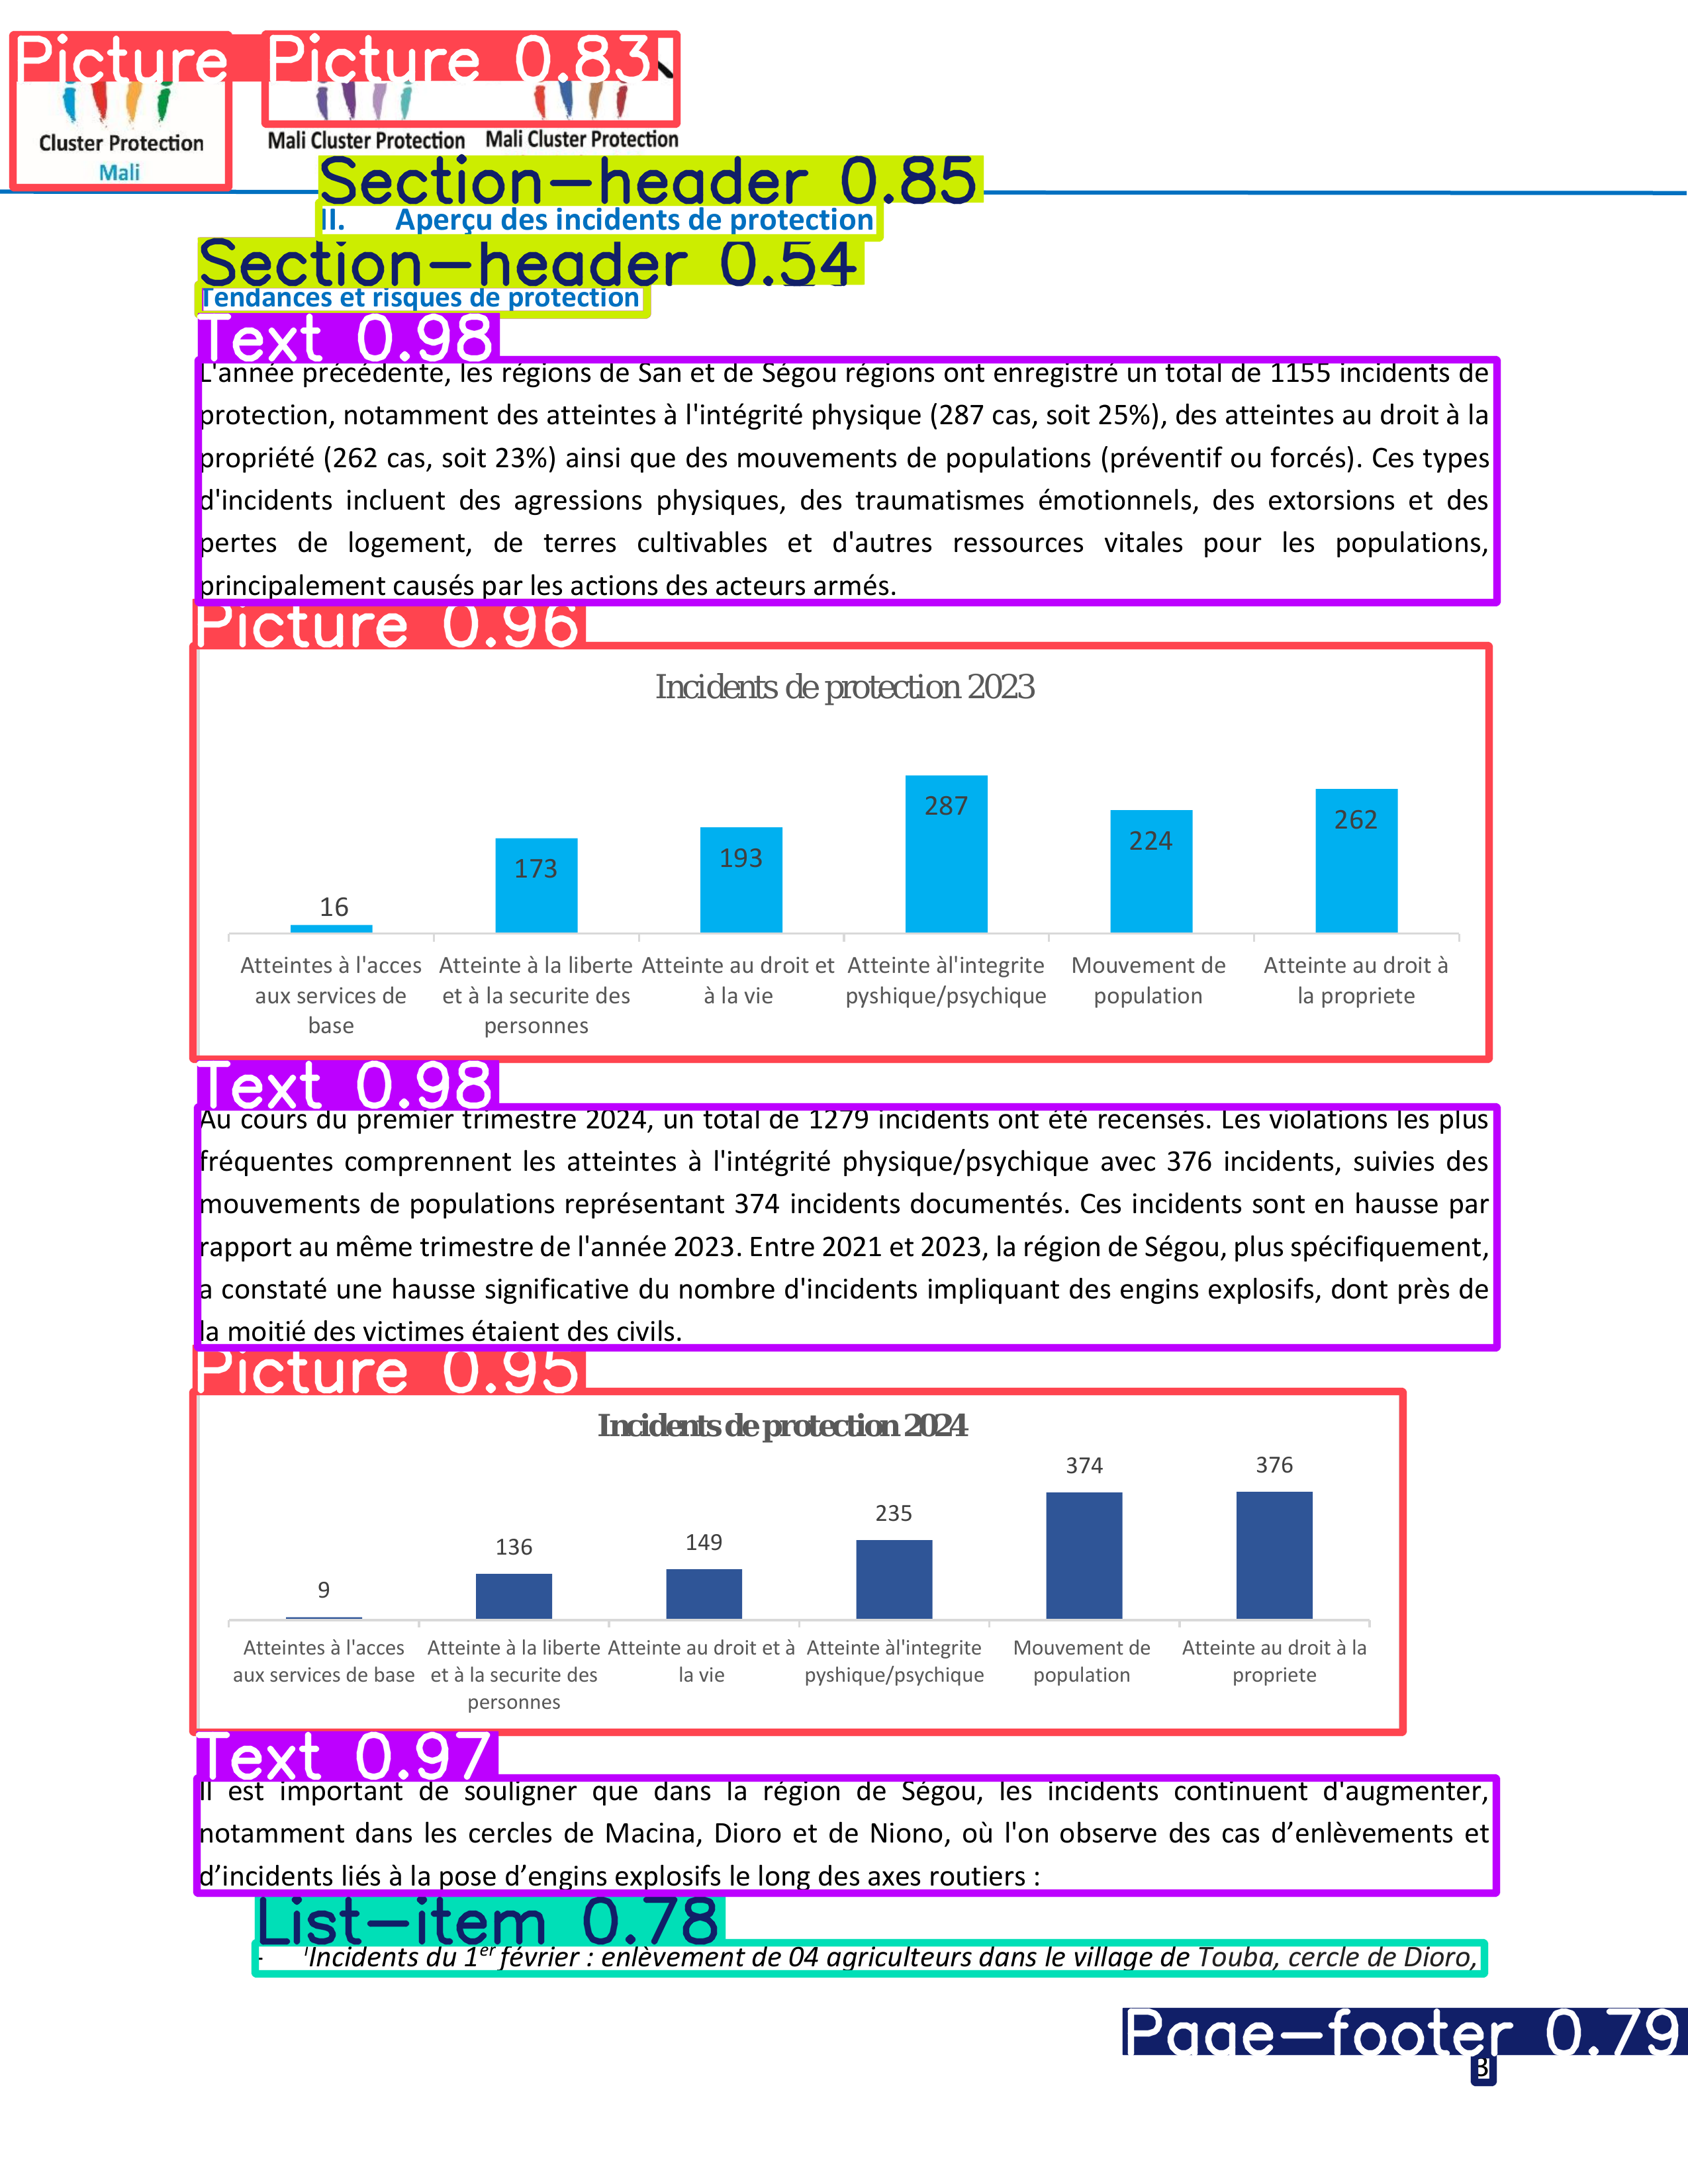

In [5]:
res[0].show()